### 1. Import thư viện 

In [62]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### 2. Load dataset

In [63]:
df = pd.read_csv("../data/fire_dataset.csv")

print("Dataset shape:", df.shape)
df.head(20)

Dataset shape: (16607, 5)


,timestamp,temp,humidity,gas,label
0,2026-03-05 09:50:03,29.75,69.51,507,0
1,2026-03-05 09:50:04,29.76,69.47,501,0
2,2026-03-05 09:50:05,29.75,69.42,503,0
3,2026-03-05 09:50:06,29.76,69.81,503,0
4,2026-03-05 09:50:07,29.78,70.05,502,0
5,2026-03-05 09:50:07,29.78,70.05,505,0
6,2026-03-05 09:50:08,29.76,70.13,502,0
7,2026-03-05 09:50:09,29.76,70.13,495,0
8,2026-03-05 09:50:09,29.77,70.12,505,0
9,2026-03-05 09:50:10,29.77,70.12,507,0


### 3. Kiểm tra dữ liệu ban đầu

In [64]:
# Thông tin tổng quan
df.info()
df.drop(columns='label').describe()

<class 'pandas.DataFrame'>
RangeIndex: 16607 entries, 0 to 16606
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  16607 non-null  str    
 1   temp       16607 non-null  float64
 2   humidity   16607 non-null  float64
 3   gas        16607 non-null  int64  
 4   label      16607 non-null  int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 648.8 KB


,temp,humidity,gas
count,16607.000000,16607.000000,16607.000000
mean,31.465659,73.444770,1003.801168
std,35.979414,213.265609,729.462787
min,0.000000,0.000000,1.000000
25%,29.630000,60.950000,539.000000
50%,30.860000,65.260000,661.000000
75%,31.440000,68.780000,1161.000000
max,3202.000000,7741.000000,4095.000000


In [65]:
# Kiểm tra phân bố nhãn (0 là Normal, 1 là Gas Leak, 2 là Burning)
df['label'].value_counts()

label
0    8492
1    4654
2    3461
Name: count, dtype: int64

### 4. Làm sạch dữ liệu (Lọc lỗi cảm biến)

In [66]:
df_clean = df[
    (df['temp'] >= 18) &
    (df['humidity'] >= 20) &
    (df['humidity'] <= 100) &
    (df['gas'] >= 50) &
    (df['gas'] <= 4095)
]

df_clean = df_clean.reset_index(drop=True) # Đặt lại chỉ số sau khi lọc dữ liệu

print("Before cleaning:", len(df))
print("After cleaning:", len(df_clean))

Before cleaning: 16607
After cleaning: 16379


### 5. Distribution

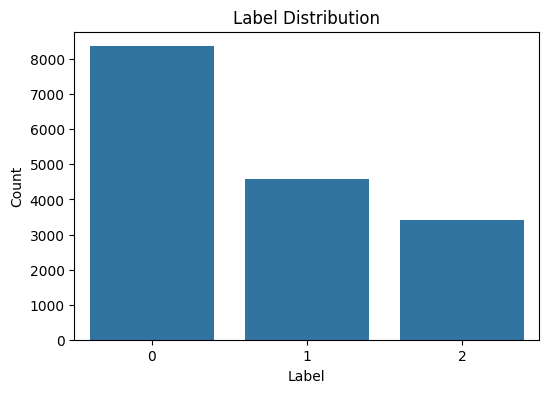

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_clean)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

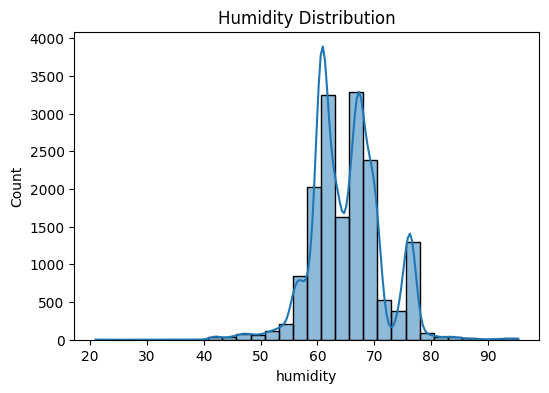

In [68]:
# Humidity Distribution
plt.figure(figsize=(6,4))
sns.histplot(df_clean['humidity'], bins=30, kde=True)

plt.title("Humidity Distribution")
plt.show()

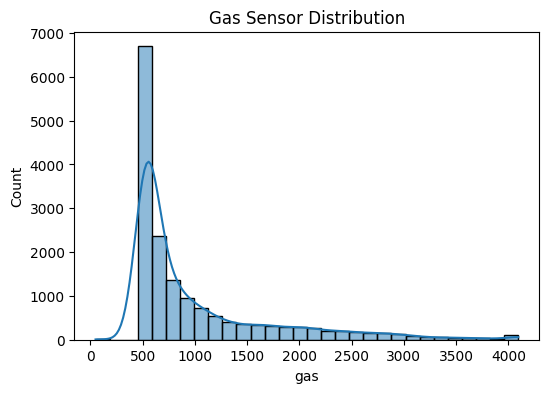

In [69]:
# Gas Sensor Distribution
plt.figure(figsize=(6,4))
sns.histplot(df_clean['gas'], bins=30, kde=True)

plt.title("Gas Sensor Distribution")
plt.show()

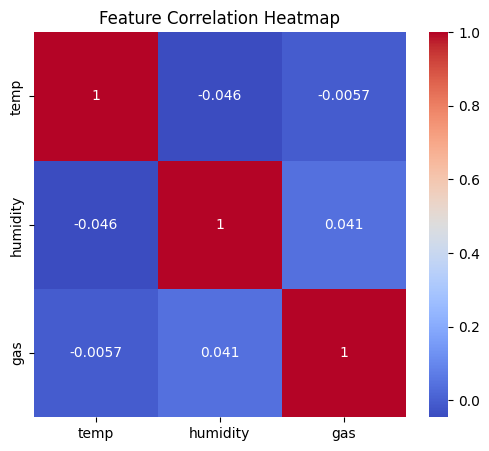

In [70]:
# Feature Correlation Heatmap
corr = df_clean[['temp','humidity','gas']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

### 6. Feature Engineering
- Thêm biến biến thiên của temp, gas (phát hiện cháy dễ hơn...)

In [71]:
df_clean['temp_diff'] = df_clean['temp'].diff()
df_clean['gas_diff'] = df_clean['gas'].diff()

df_clean = df_clean.fillna(0)

### 7. Lựa chọn đặc trưng (Feature Selection)

In [72]:
features = [
    'temp',
    'humidity',
    'gas',
    'temp_diff',
    'gas_diff'
    # 'hour' có thể thêm bằng cách trích xuất từ timestamp 
]

X = df_clean[features]
y = df_clean['label']

### 8. Train/Test Split

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (13103, 5)
Test size: (3276, 5)


### 9. Random Forest and Predict

In [74]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 8. Đánh giá model

In [75]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9853479853479854


In [76]:
# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal","Gas Leak","Burning"]
))

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1673
    Gas Leak       0.99      0.99      0.99       919
     Burning       0.96      0.97      0.97       684

    accuracy                           0.99      3276
   macro avg       0.98      0.98      0.98      3276
weighted avg       0.99      0.99      0.99      3276



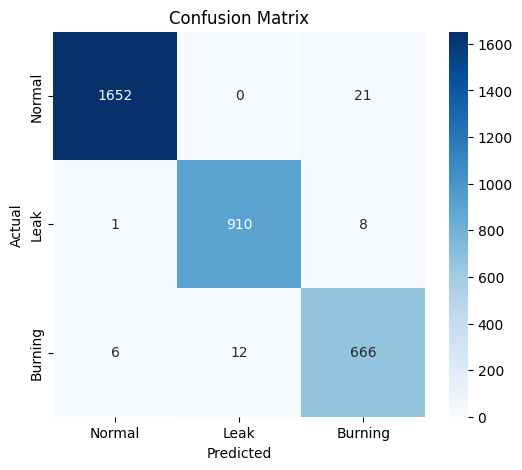

In [77]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Normal","Leak","Burning"],
            yticklabels=["Normal","Leak","Burning"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Feature importance

In [78]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': importances   
})

feature_importance.sort_values(by='importance', ascending=False)

,feature,importance
2,gas,0.499697
0,temp,0.268402
1,humidity,0.126983
4,gas_diff,0.092937
3,temp_diff,0.011980


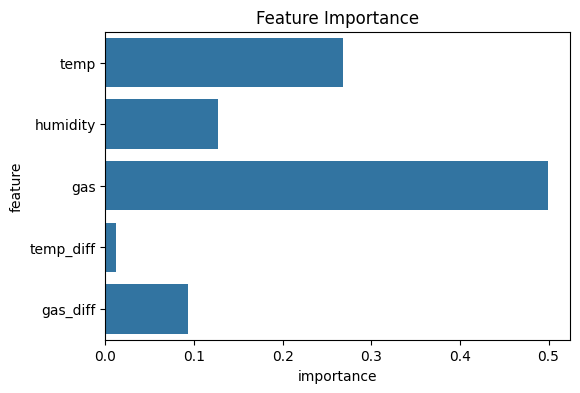

In [79]:
# Visualize feature importance
plt.figure(figsize=(6,4))

sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

# Save model and Test sample...

In [80]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")
model = joblib.load("../models/random_forest_model.pkl")

In [81]:
sample = pd.DataFrame({
    'temp':[45],
    'humidity':[40],
    'gas':[2200],
    'temp_diff':[5],
    'gas_diff':[500]
})

prediction = model.predict(sample)

print(prediction)

[2]


End...